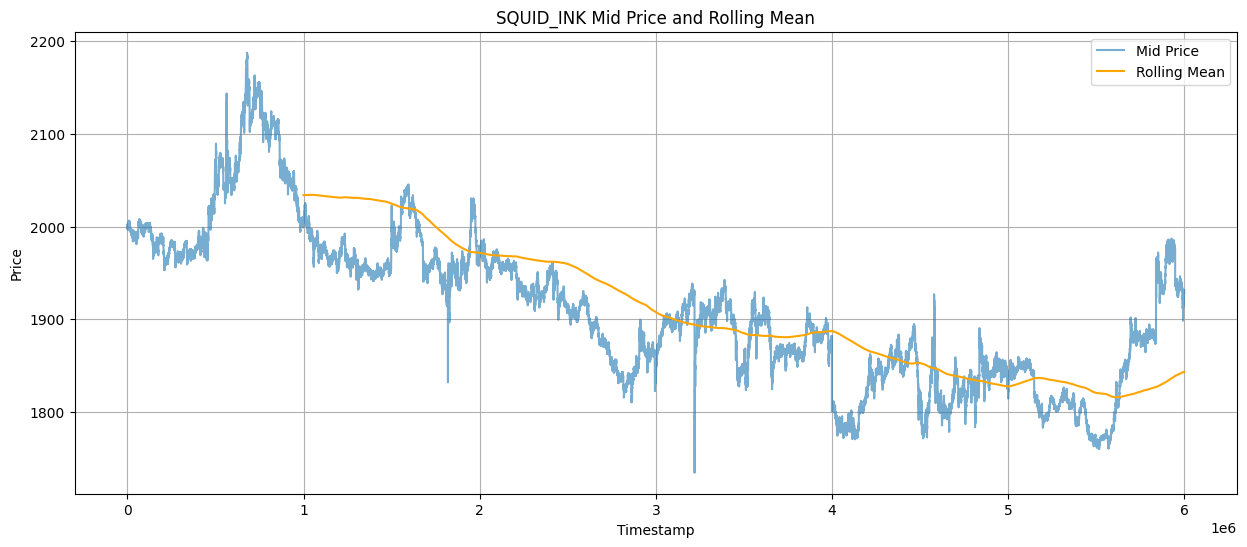

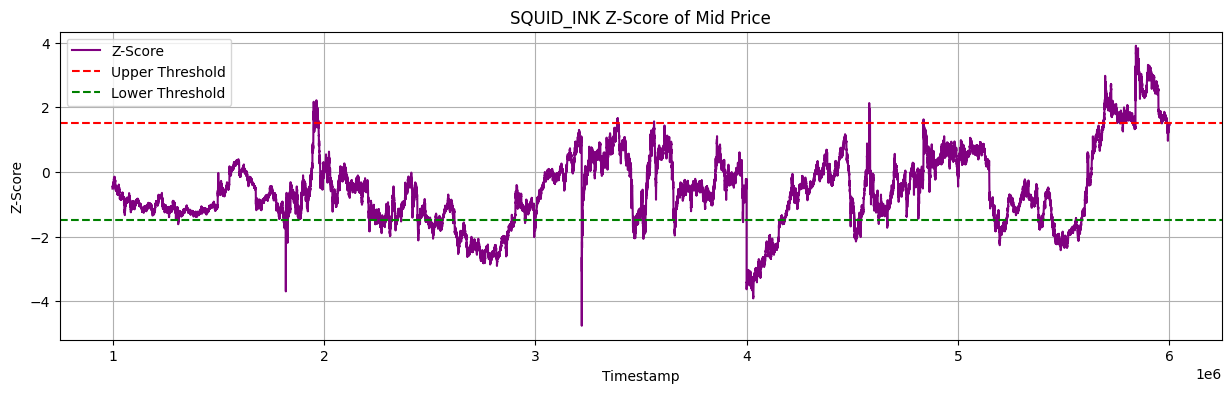

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Load and combine the data files
files = [
    "data/prices_round_1_day_-2.csv",
    "data/prices_round_2_day_-1.csv",
    "data/prices_round_3_day_0.csv",
    "data/prices_round_4_day_1.csv",
    "data/prices_round_4_day_2.csv",
    "data/prices_round_4_day_3.csv"
]

df_list = []
timestamp_offset = 0

for file in files:
    if os.path.exists(file):
        df = pd.read_csv(file, sep=';')
        df['timestamp'] += timestamp_offset
        timestamp_offset = df['timestamp'].max() + 1
        df_list.append(df)
    else:
        print(f"File not found: {file}")

# Proceed only if data is loaded
if df_list:
    data = pd.concat(df_list, ignore_index=True)

    # Filter data for SQUID_INK
    squid_data = data[data['product'] == 'SQUID_INK'].copy()

    # Sort by timestamp to ensure correct time ordering
    squid_data.sort_values(by='timestamp', inplace=True)

    # Calculate rolling mean and standard deviation of mid_price
    window_size = 10000
    squid_data['rolling_mean'] = squid_data['mid_price'].rolling(window=window_size).mean()
    squid_data['rolling_std'] = squid_data['mid_price'].rolling(window=window_size).std()

    # Calculate z-score
    squid_data['z_score'] = (squid_data['mid_price'] - squid_data['rolling_mean']) / squid_data['rolling_std']

    # Plotting the mid_price and rolling mean
    plt.figure(figsize=(15, 6))
    plt.plot(squid_data['timestamp'], squid_data['mid_price'], label='Mid Price', alpha=0.6)
    plt.plot(squid_data['timestamp'], squid_data['rolling_mean'], label='Rolling Mean', color='orange')
    plt.title('SQUID_INK Mid Price and Rolling Mean')
    plt.xlabel('Timestamp')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plotting the z-score
    plt.figure(figsize=(15, 4))
    plt.plot(squid_data['timestamp'], squid_data['z_score'], label='Z-Score', color='purple')
    plt.axhline(1.5, color='red', linestyle='--', label='Upper Threshold')
    plt.axhline(-1.5, color='green', linestyle='--', label='Lower Threshold')
    plt.title('SQUID_INK Z-Score of Mid Price')
    plt.xlabel('Timestamp')
    plt.ylabel('Z-Score')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No data files were loaded. Please check the file paths.")
